---
title: "Sea Ice"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Sea Ice Extent
- **description:** Daily Arctic sea-ice extent derived from satellite passive-microwave sensors, tracking the seasonal and long-term retreat of the polar ice cap from 1980 to 2019.
- **provenance:** National Snow and Ice Data Center (NSIDC) Sea Ice Index.
- **format:** long / tidy time series — 13,175 rows x 2 columns.

**Data dictionary**

- `Date` — *(identifier)* the day of observation (`yyyy-mm-dd`), from `1980-01-01` to `2019-12-31`.
- `Extent` — *(measurement)* ice area in millions of square kilometres; every 25 km x 25 km grid cell with at least 15% ice concentration is counted.

**Structure**

- **Rows:** 13,175 — one row per day.
- **Columns:** 2.
- **Identifiers:** `Date`.
- **Measurements:** `Extent`.

**Use cases**

- line graphs showing seasonality and long-term decline
- year x month heatmaps for a vivid view of aggregated data
- bar plots of annual means showing overall change


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Long form

In [3]:
seaice = sns.load_dataset('seaice')
seaice

,Date,Extent
0,1980-01-01,14.200
1,1980-01-03,14.302
2,1980-01-05,14.414
3,1980-01-07,14.518
4,1980-01-09,14.594
...,...,...
13170,2019-12-27,12.721
13171,2019-12-28,12.712
13172,2019-12-29,12.780
13173,2019-12-30,12.858


In [4]:
seaice.info()

<class 'pandas.DataFrame'>
RangeIndex: 13175 entries, 0 to 13174
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    13175 non-null  datetime64[us]
 1   Extent  13175 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 206.0 KB


## Long form with key index

In [5]:
seaice1 = seaice.set_index('Date')
seaice1

,Extent
Date,
1980-01-01,14.200
1980-01-03,14.302
1980-01-05,14.414
1980-01-07,14.518
1980-01-09,14.594
...,...
2019-12-27,12.721
2019-12-28,12.712
2019-12-29,12.780


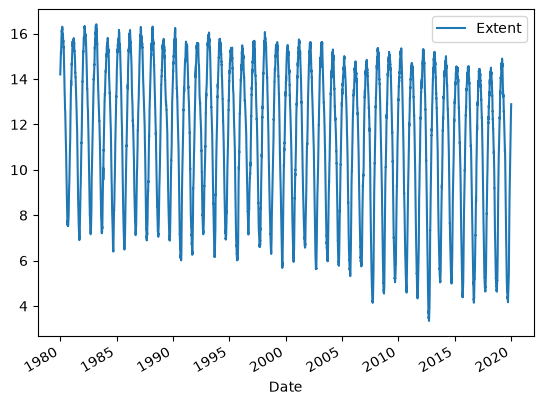

In [6]:
seaice1.plot()
plt.show()

## Long form with expanded date as key index

In [7]:
seaice2 = seaice.copy()
seaice2['Date'] = pd.to_datetime(seaice['Date'])
seaice2['year'] = seaice2.Date.dt.year
seaice2['month'] = seaice2.Date.dt.month
seaice2['day'] = seaice2.Date.dt.day
seaice2 = seaice2.drop('Date', axis=1)
seaice2 = seaice2.set_index(['year','month','day']).sort_index()
seaice2

Extent
year month day        
1980 1     1    14.200
           3    14.302
           5    14.414
           7    14.518
           9    14.594
...                ...
2019 12    27   12.721
           28   12.712
           29   12.780
           30   12.858
           31   12.889

[13175 rows x 1 columns]

### Long form aggregated by year

In [22]:
seaice3 = seaice2.groupby('year').agg(
    extent_mean = ('Extent','mean'),
    extent_min = ('Extent','min'),
    extent_max = ('Extent','max'),
    extent_std = ('Extent','std')
)
seaice3

,extent_mean,extent_min,extent_max,extent_std
year,,,,
1980,12.334148,7.533,16.302,2.970653
1981,12.135486,6.902,15.801,2.975248
1982,12.439445,7.160,16.325,3.001320
1983,12.335896,7.204,16.412,2.906828
1984,11.912601,6.396,15.809,2.988544
1985,11.986599,6.486,16.163,3.188037
1986,12.208224,7.122,16.158,2.881975
1987,11.397227,6.890,16.293,3.163364
1988,12.093169,7.048,16.309,2.984991


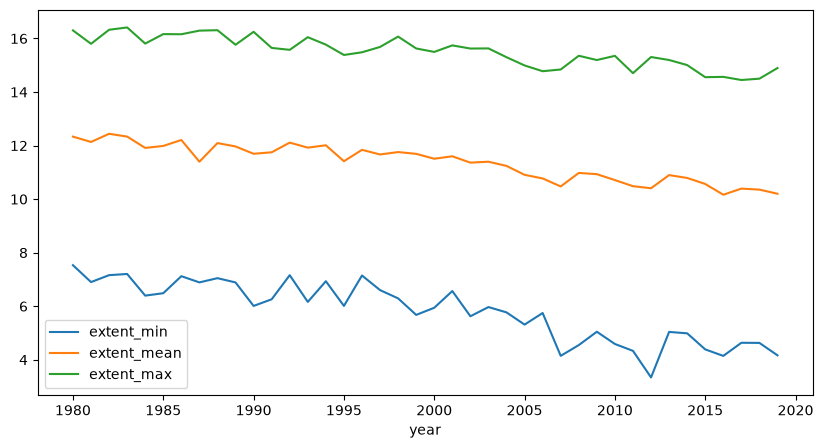

In [29]:
seaice3[['extent_min', 'extent_mean', 'extent_max']].plot.line(figsize=(10,5))
plt.show()

### Wide form 1 by 1

In [11]:
seaice4 = seaice2.groupby(['year','month']).Extent.mean().unstack()
seaice4

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1980,14.861875,15.955143,16.041313,15.429067,13.792600,12.204600,10.100062,7.984267,7.667067,9.182750,11.382867,13.592933
1981,14.909688,15.604071,15.631533,15.009933,13.801625,12.429733,10.271000,7.844313,7.138467,8.856267,10.929000,13.341125
1982,15.176733,15.973500,16.043875,15.466000,13.973200,12.476067,10.367062,8.139533,7.301733,9.421062,11.627467,13.641800
1983,14.942438,16.006143,16.085267,15.172067,13.491312,12.295667,10.570267,8.185875,7.394600,9.334067,11.461000,13.298438
1984,14.473267,15.298933,15.584200,15.014467,13.576688,12.151667,9.977533,7.771063,6.805200,8.560600,10.841533,12.989437
1985,14.724867,15.465714,15.885938,15.356533,14.073400,12.219067,9.744563,7.401867,6.697667,8.545938,11.024533,13.049933
1986,14.889625,15.784857,15.909467,15.058800,13.379563,11.975933,10.146467,7.979563,7.410667,9.483933,11.453267,13.222437
1987,14.969800,16.050143,15.815938,15.210867,13.742933,12.485667,10.332562,7.499905,7.278700,9.048774,11.224033,12.540500
1988,15.090474,15.583379,15.957226,15.123333,13.560871,11.943433,9.808677,7.891581,7.369000,9.135032,11.330833,13.625548


In [37]:
seaice4.T.style.format(precision=2).background_gradient(cmap='Reds_r', axis=None)

year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,14.86,14.91,15.18,14.94,14.47,14.72,14.89,14.97,15.09,14.95,14.78,14.36,14.64,14.90,14.73,14.59,14.18,14.42,14.72,14.36,14.22,14.20,14.27,14.39,14.03,13.66,13.47,13.70,13.89,13.91,13.74,13.46,13.73,13.70,13.65,13.60,13.46,13.19,13.08,13.57
2,15.96,15.60,15.97,16.01,15.30,15.47,15.78,16.05,15.58,15.50,15.58,15.25,15.46,15.69,15.56,15.23,15.15,15.44,15.75,15.31,15.14,15.21,15.34,15.19,14.91,14.37,14.32,14.51,14.95,14.81,14.58,14.36,14.55,14.72,14.42,14.40,14.20,14.12,13.97,14.39
3,16.04,15.63,16.04,16.09,15.58,15.89,15.91,15.82,15.96,15.42,15.87,15.42,15.48,15.81,15.55,15.26,15.12,15.47,15.60,15.40,15.22,15.52,15.35,15.48,14.99,14.69,14.42,14.54,15.18,14.98,15.14,14.55,15.20,15.03,14.76,14.37,14.40,14.29,14.30,14.57
4,15.43,15.01,15.47,15.17,15.01,15.36,15.06,15.21,15.12,14.33,14.65,14.86,14.68,15.08,14.89,14.45,14.22,14.56,14.89,15.08,14.56,14.86,14.30,14.51,13.99,14.09,13.91,13.85,14.35,14.50,14.66,14.11,14.63,14.30,14.09,13.89,13.68,13.75,13.70,13.43
5,13.79,13.80,13.97,13.49,13.58,14.07,13.38,13.74,13.56,13.04,13.23,13.47,13.22,13.37,13.62,12.97,13.09,13.18,13.59,13.75,13.15,13.51,12.97,13.02,12.56,12.91,12.52,12.78,12.97,13.19,12.87,12.68,13.01,13.00,12.70,12.47,11.92,12.63,12.23,12.19
6,12.20,12.43,12.48,12.30,12.15,12.22,11.98,12.49,11.94,12.24,11.64,12.11,12.15,11.87,12.02,11.44,12.08,11.74,11.71,11.78,11.67,11.46,11.58,11.60,11.45,11.16,10.92,11.22,11.21,11.32,10.59,10.75,10.67,11.36,11.03,10.88,10.41,10.76,10.78,10.59
7,10.10,10.27,10.37,10.57,9.98,9.74,10.15,10.33,9.81,10.13,9.25,9.51,10.32,9.48,9.93,8.99,10.16,9.41,9.42,9.49,9.51,9.07,9.27,9.21,9.43,8.65,8.46,7.94,8.68,8.47,8.07,7.72,7.67,8.13,8.11,8.38,7.94,7.94,8.27,7.59
8,7.98,7.84,8.14,8.19,7.77,7.40,7.98,7.50,7.89,7.88,6.80,7.42,7.93,7.33,7.64,6.74,8.18,7.29,7.51,7.23,7.17,7.46,6.60,6.94,6.85,6.30,6.50,5.34,5.91,6.14,5.87,5.50,4.72,6.01,6.08,5.60,5.37,5.48,5.61,5.03
9,7.67,7.14,7.30,7.39,6.81,6.70,7.41,7.28,7.37,7.01,6.14,6.47,7.47,6.40,7.14,6.08,7.58,6.69,6.54,6.12,6.25,6.73,5.83,6.12,5.98,5.50,5.86,4.27,4.69,5.26,4.87,4.56,3.57,5.21,5.22,4.62,4.53,4.82,4.79,4.36


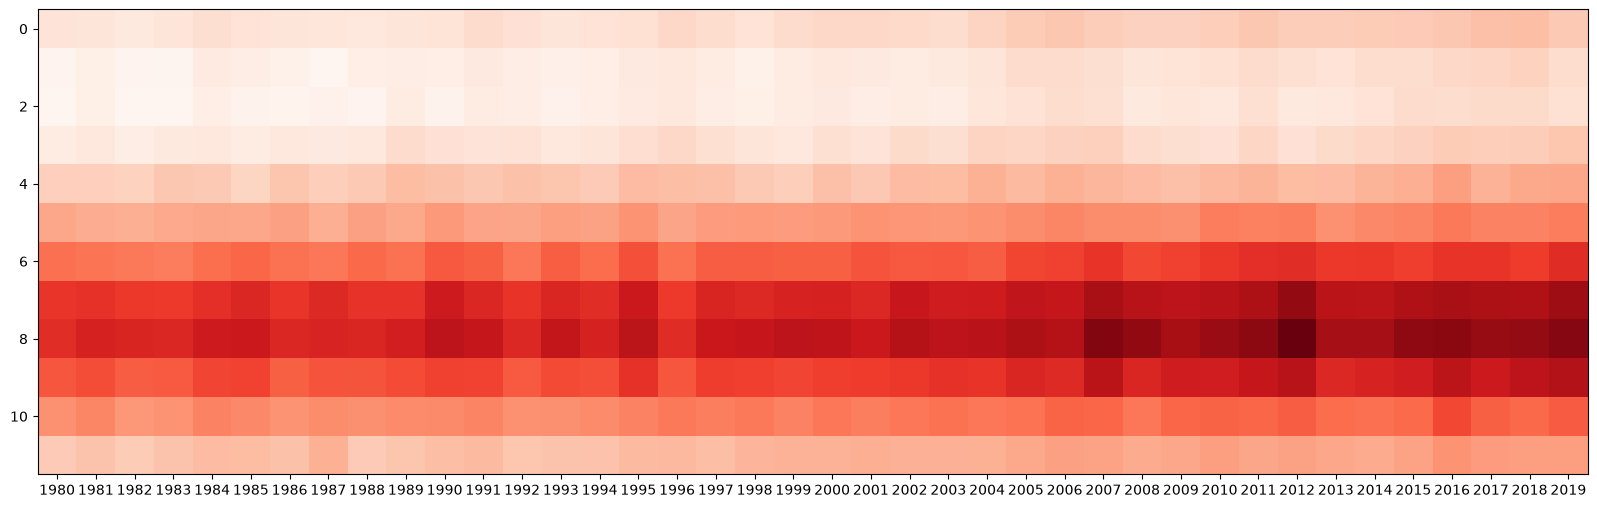

In [30]:
fig, ax = plt.subplots(figsize=(20,10))
plt.imshow(seaice4.T, cmap='Reds_r')
ax.set_xticks([i for i in range(seaice4.shape[0])])
ax.set_xticklabels(seaice4.index)
plt.show()

### Long form aggregated by year and month with key index

In [33]:
seaice5 = seaice4.stack().to_frame('Extent')
seaice5

Extent
year month           
1980 1      14.861875
     2      15.955143
     3      16.041313
     4      15.429067
     5      13.792600
...               ...
2019 8       5.026323
     9       4.363900
     10      5.734903
     11      9.352833
     12     11.903097

[480 rows x 1 columns]

In [36]:
seaice2.groupby(['year','month']).Extent.mean().to_frame('Extent')

Extent
year month           
1980 1      14.861875
     2      15.955143
     3      16.041313
     4      15.429067
     5      13.792600
...               ...
2019 8       5.026323
     9       4.363900
     10      5.734903
     11      9.352833
     12     11.903097

[480 rows x 1 columns]